In [2]:
import numpy as np
import pandas as pd

In [3]:
df=pd.read_csv(r"C:\Users\Isha\Desktop\AI_ML\UPI_Fraud_Detection\Dataset\upi_transaction.csv")

In [4]:

# 1. Basic Data Inspection


print("Dataset Shape:", df.shape)
print(df.head())
print(df.info())

Dataset Shape: (10000, 63)
  transaction_id    utr_number         timestamp sender_id     sender_vpa  \
0     TXN0000001  8.020000e+11  22-06-2026 01:42     U0230      u0230@apl   
1     TXN0000002  8.440000e+11  22-06-2026 01:50     U0230      u0230@apl   
2     TXN0000003  1.990000e+11  22-06-2026 04:42     U0224  u0224@okicici   
3     TXN0000004  4.550000e+11  22-06-2026 06:37     U0045    u0045@axisb   
4     TXN0000005  9.240000e+11  22-06-2026 07:36     U0148  u0148@okicici   

  receiver_id             receiver_vpa receiver_type  amount_inr  \
0      M00675     wallet675@okhdfcbank      Merchant     13500.0   
1      M00675     wallet675@okhdfcbank      Merchant     13500.0   
2      P00391             p00391@axisb        Person     42100.0   
3      M00596         fashion596@paytm      Merchant      1559.0   
4      M00320  transport320@okhdfcbank      Merchant       101.0   

   merchant_category  ...  speed_kmph_from_prev receiver_account_age_days  \
0      Wallet Top-up  ..

In [5]:
# Missing Values

print(df.isnull().sum())

transaction_id                0
utr_number                    0
timestamp                     0
sender_id                     0
sender_vpa                    0
                             ..
receiver_unique_senders_7d    0
risk_score                    0
risk_level                    0
is_suspicious                 0
anomaly_pattern               0
Length: 63, dtype: int64


In [6]:
# Duplicate values

print(df.duplicated().sum())

0


In [7]:
# -------------------------------
# 2. Feature Engineering
# -------------------------------

# Average transaction amount per sender
df["sender_avg_amount"] = (df.groupby("sender_id")["amount_inr"].transform("mean"))

# Difference from user's average transaction
df["amount_deviation"] = (
    df["amount_inr"] - df["sender_avg_amount"]
)
# Ratio
df["amount_ratio"] = ( df["amount_inr"] / df["sender_avg_amount"].replace(0, np.nan) ) 

df["amount_ratio"] = df["amount_ratio"].fillna(0)


In [8]:
 #  User Transaction Frequency 
df["user_transaction_count"] = ( df.groupby("sender_id")["sender_vpa"].transform("count"))


In [9]:
#  Recipient Frequency 
df["recipient_transaction_count"] = ( df.groupby("receiver_id")["receiver_vpa"] .transform("count") )

In [10]:

#  Device Change Indicator
# -------------------------------

df["previous_device"] = (
    df.groupby("sender_id")["device_id"].shift(1)
)

df["device_change"] = (
    df["device_id"] != df["previous_device"]
).astype(int)

# First transaction for a user should not automatically
# be considered a device change
df.loc[df["previous_device"].isna(), "device_change"] = 0


In [11]:
print(df["device_change"])

0       0
1       0
2       0
3       0
4       0
       ..
9995    0
9996    0
9997    0
9998    0
9999    0
Name: device_change, Length: 10000, dtype: int64


In [12]:
#--------------------------------------
# 3. Applying IQR
#-------------------------------------

Q1 = df["amount_inr"].quantile(0.25)
Q3 = df["amount_inr"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df["iqr_outlier"] = (
    (df["amount_inr"] < lower_bound) |
    (df["amount_inr"] > upper_bound)
).astype(int)

In [13]:
print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

print(df["iqr_outlier"].value_counts())

Q1: 332.08750000000003
Q3: 1624.0
IQR: 1291.9125
Lower Bound: -1605.7812499999998
Upper Bound: 3561.8687499999996
iqr_outlier
0    8815
1    1185
Name: count, dtype: int64


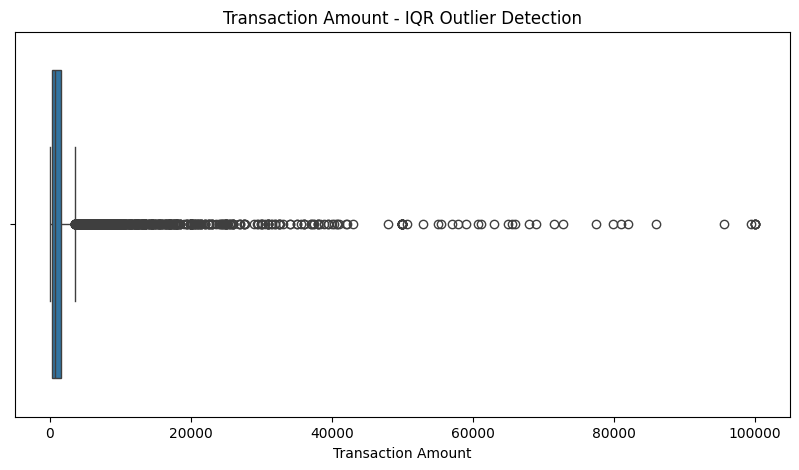

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))

sns.boxplot(x=df["amount_inr"])

plt.title("Transaction Amount - IQR Outlier Detection")
plt.xlabel("Transaction Amount")

plt.show()

In [15]:
#----------------------------------------------------
# 4: Use Isolation Forest for anomaly detection
#----------------------------------------------------

from sklearn.ensemble import IsolationForest
# Selecting all the numerical values
X = df.select_dtypes(include=["int64", "float64"])
X = X.drop(columns=["utr_number", "is_suspicious", "risk_score", "iqr_outlier"], errors="ignore")
print(X.columns.tolist()) 


['amount_inr', 'mcc', 'latitude', 'longitude', 'distance_from_home_km', 'device_age_hours', 'is_new_device', 'is_rooted_or_emulator', 'sim_swap_last_7d', 'hour_of_day', 'day_of_month', 'is_weekend', 'is_night_txn', 'usual_hour_start', 'usual_hour_end', 'is_unusual_hour', 'sender_account_age_days', 'hist_avg_amount', 'hist_std_amount', 'hist_avg_daily_txns', 'balance_before_txn', 'amount_to_balance_ratio', 'amount_to_hist_avg_ratio', 'amount_zscore', 'txn_count_last_1h', 'txn_count_last_24h', 'amount_sum_last_24h', 'mins_since_prev_txn', 'km_from_prev_txn', 'speed_kmph_from_prev', 'receiver_account_age_days', 'is_first_time_receiver', 'same_receiver_txn_count_24h', 'same_receiver_txn_count_7d', 'receiver_unique_senders_7d', 'sender_avg_amount', 'amount_deviation', 'amount_ratio', 'user_transaction_count', 'recipient_transaction_count', 'device_change']


In [16]:
# Isolation forest

model = IsolationForest(
    n_estimators=100,
    contamination=0.05,
    random_state=42
)

In [17]:
# Train and predict anomalies
df["anomaly_prediction"] = model.fit_predict(X)

In [18]:
# create fraud / anomal column
df["is_anomaly"] = df["anomaly_prediction"].apply(lambda x: 1 if x == -1 else 0)

In [19]:
# Count anomalies

print("Total transactions:", len(df))
print("Potential anomalies:", df["is_anomaly"].sum())

Total transactions: 10000
Potential anomalies: 500


In [20]:
# In % 
anomaly_percentage = df["is_anomaly"].mean() * 100
print("Anomaly percentage:", anomaly_percentage)

Anomaly percentage: 5.0


In [21]:
# Suspious Transaction

suspicious_transactions = df[df["is_anomaly"] == 1]
print(suspicious_transactions.head())

   transaction_id    utr_number         timestamp sender_id     sender_vpa  \
0      TXN0000001  8.020000e+11  22-06-2026 01:42     U0230      u0230@apl   
1      TXN0000002  8.440000e+11  22-06-2026 01:50     U0230      u0230@apl   
2      TXN0000003  1.990000e+11  22-06-2026 04:42     U0224  u0224@okicici   
30     TXN0000031  8.230000e+11  22-06-2026 12:07     U0149      u0149@ybl   
31     TXN0000032  3.650000e+11  22-06-2026 12:10     U0114      u0114@ybl   

   receiver_id          receiver_vpa receiver_type  amount_inr  \
0       M00675  wallet675@okhdfcbank      Merchant     13500.0   
1       M00675  wallet675@okhdfcbank      Merchant     13500.0   
2       P00391          p00391@axisb        Person     42100.0   
30      M00603  online603@okhdfcbank      Merchant     10500.0   
31      P00377            p00377@ybl        Person     20700.0   

   merchant_category  ...  sender_avg_amount amount_deviation amount_ratio  \
0      Wallet Top-up  ...        1558.166250     11941.8

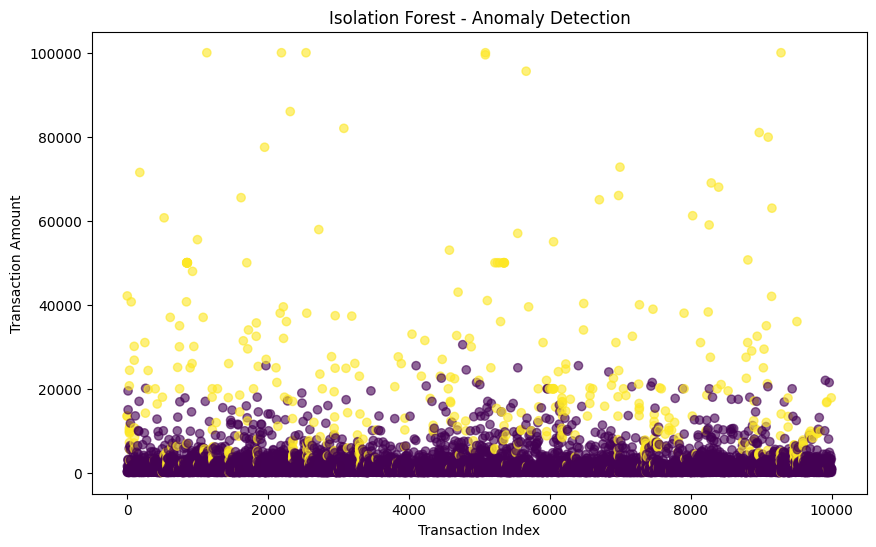

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.scatter(
    df.index,
    df["amount_inr"],
    c=df["is_anomaly"],
    alpha=0.6
)

plt.xlabel("Transaction Index")
plt.ylabel("Transaction Amount")
plt.title("Isolation Forest - Anomaly Detection")

plt.show()

In [23]:
#---------------------------
# 5. Time series
#-------------------------

# Time stamp

df["timestamp"] = pd.to_datetime(df["timestamp"])  # Convert 22-06-2026  01:42:17 into object

df["hour"] = df["timestamp"].dt.hour  #1 hr
df["date"] = df["timestamp"].dt.date  # per date
df["day"] = df["timestamp"].dt.day    # number of days
df["day_of_week"] = df["timestamp"].dt.dayofweek   #  0-Monday  ...............
df["is_weekend"] = df["day_of_week"].isin([5, 6]).astype(int)  # is in [sat sun]

C:\Users\Isha\AppData\Local\Temp\ipykernel_18960\1636115957.py:7: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["timestamp"] = pd.to_datetime(df["timestamp"])  # Convert 22-06-2026  01:42:17 into object


In [24]:
df = df.sort_values(["sender_id", "timestamp"])

In [25]:

    # Hourly transaction
hourly_transactions = df.groupby("hour").size()
print(hourly_transactions)


hour
0      32
1      27
2      56
3      22
4      44
5      25
6      47
7     189
8     342
9     445
10    589
11    711
12    748
13    663
14    543
15    538
16    583
17    709
18    843
19    899
20    870
21    653
22    312
23    110
dtype: int64


In [26]:
# Amount spent per day
daily_amount = df.groupby("date")["amount_inr"].sum()
print(daily_amount)

date
2026-06-22    424561.64
2026-06-23    150676.28
2026-06-24    230400.75
2026-06-25    156714.35
2026-06-26    186284.35
                ...    
2026-09-15    254906.41
2026-09-16    133841.75
2026-09-17    164169.65
2026-09-18    159176.28
2026-09-19    194601.47
Name: amount_inr, Length: 90, dtype: float64


In [27]:
# Daily time series
daily_transactions = (
    df.set_index("timestamp")
      .resample("D")
      .size()
)

In [28]:
# Adding rolling statistics
daily_transactions_rolling = daily_transactions.rolling(7).mean()  # 7 days rolling

daily_std = daily_transactions.rolling(7).std()

In [29]:
#Detect unusual spikes
upper_limit = (
    daily_transactions_rolling
    + 2 * daily_std
)
time_anomaly = (
    daily_transactions > upper_limit
).astype(int)

In [30]:
print(daily_transactions[time_anomaly])   # Transaction is high some wgere

timestamp
2026-06-22    102
2026-06-22    102
2026-06-22    102
2026-06-22    102
2026-06-22    102
             ... 
2026-06-22    102
2026-06-22    102
2026-06-22    102
2026-06-22    102
2026-06-22    102
Length: 90, dtype: int64


C:\Users\Isha\AppData\Local\Temp\ipykernel_18960\3553253842.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(daily_transactions[time_anomaly])   # Transaction is high some wgere


In [31]:
# Convert anomaly index to Python date
time_anomaly.index = time_anomaly.index.date

# Map daily anomaly back to original transactions
df["time_anomaly"] = (
    df["date"]
    .map(time_anomaly)
    .fillna(0)
    .astype(int)
)

In [32]:
#---------------------------------------------------------
#     Step 6: Combine the methods into one fraud logic
#-----------------------------------------------------------

df["risk_score"] = (
    df["iqr_outlier"]
    + df["is_anomaly"]
    + df["time_anomaly"]
)

In [33]:
# Convert the score into a risk level

def risk_level(score):
    if score == 0:
        return "Normal"
    elif score == 1:
        return "Review"
    else:
        return "High Risk"

df["risk_level"] = df["risk_score"].apply(risk_level)

In [34]:
print(df[["iqr_outlier", "is_anomaly", "time_anomaly", "risk_score", "risk_level"]].head(20))

      iqr_outlier  is_anomaly  time_anomaly  risk_score risk_level
420             0           0             0           0     Normal
803             0           0             0           0     Normal
4376            0           0             0           0     Normal
6123            0           0             0           0     Normal
9591            0           1             0           1     Review
9592            1           1             0           2  High Risk
9593            0           1             0           1     Review
9594            1           1             0           2  High Risk
9595            1           1             0           2  High Risk
9596            1           1             0           2  High Risk
9597            1           1             0           2  High Risk
94              0           0             0           0     Normal
253             0           0             0           0     Normal
426             0           0             0           0     No

In [35]:
df.rename(columns={
    "risk_score": "final_risk_score",
    "risk_level": "final_risk_level"
}, inplace=True)

In [36]:
#-------------------------------------------------------------
# 7: Build a backend server for real-time alerts
#-------------------------------------------------------------
import joblib

joblib.dump(model, "isolation_forest.pkl")

['isolation_forest.pkl']

In [37]:
model = joblib.load("isolation_forest.pkl")

In [38]:
# Save new CSV
df.to_csv(
    "C:/Users/Isha/Desktop/AI_ML/UPI_Fraud_Detection/Dataset/upi_transactions_analyzed.csv",
    index=False
)

print("New CSV created successfully!")

New CSV created successfully!


In [39]:
print(df.columns.tolist())

['transaction_id', 'utr_number', 'timestamp', 'sender_id', 'sender_vpa', 'receiver_id', 'receiver_vpa', 'receiver_type', 'amount_inr', 'merchant_category', 'mcc', 'transaction_type', 'initiation_mode', 'upi_app', 'sender_bank', 'txn_status', 'failure_reason', 'city', 'state', 'latitude', 'longitude', 'home_city', 'distance_from_home_km', 'device_id', 'device_type', 'device_age_hours', 'is_new_device', 'network_type', 'is_rooted_or_emulator', 'sim_swap_last_7d', 'hour_of_day', 'day_of_week', 'day_of_month', 'is_weekend', 'is_night_txn', 'usual_hour_start', 'usual_hour_end', 'is_unusual_hour', 'sender_account_age_days', 'sender_income_band', 'hist_avg_amount', 'hist_std_amount', 'hist_avg_daily_txns', 'top_spend_category', 'balance_before_txn', 'amount_to_balance_ratio', 'amount_to_hist_avg_ratio', 'amount_zscore', 'txn_count_last_1h', 'txn_count_last_24h', 'amount_sum_last_24h', 'mins_since_prev_txn', 'km_from_prev_txn', 'speed_kmph_from_prev', 'receiver_account_age_days', 'is_first_tim